# Acte 3 — Comprendre ce que le modèle a appris (V3)

Dans cet acte, on cherche à comprendre **ce que le world model encode réellement** dans son espace latent.

Le modèle a été entraîné sur un dataset dirigé, construit explicitement à partir des lois physiques du monde :

- déplacement libre
- blocage par les murs
- poussée valide
- boîte bloquée par un mur
- boîte bloquée sur la cible

---

## 🎯 Objectif

On veut répondre à plusieurs questions :

1. L'espace latent possède-t-il une structure visible ?
2. Le modèle encode-t-il la position de l'agent ?
3. Le modèle encode-t-il la position de la boîte ?
4. Le modèle encode-t-il des **propriétés physiques** du monde ?

---

## 💡 Idée clé

Une loss faible ne suffit pas.

Un bon world model ne doit pas seulement bien "fitter" les transitions :
il doit aussi construire une représentation interne structurée du monde.

## 1. Imports et initialisation

On charge :
- l'environnement
- le modèle v3
- les outils d'analyse (PCA, probing)

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.model_selection import train_test_split

from environment import GridWorld
from model import WorldModel

plt.rcParams["figure.figsize"] = (6, 5)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cpu


## 2. Chargement du modèle entraîné

On charge ici le modèle entraîné sur le dataset v3,
c’est-à-dire le dataset dirigé par lois physiques explicites.

In [2]:
model = WorldModel(latent_dim=32).to(device)
model.load_state_dict(torch.load("../data/worldmodel_v3.pt", map_location=device))
model.eval()

print("Modèle v3 chargé ✔️")

Modèle v3 chargé ✔️


## 3. Utilitaires de visualisation

On réutilise les mêmes conventions visuelles que dans l'acte 1
pour garder une continuité dans l'interprétation.

In [3]:
import matplotlib.patches as patches


def grid_to_rgb(grid):
    rgb = np.zeros((grid.shape[0], grid.shape[1], 3), dtype=np.float64)

    rgb[grid == GridWorld.EMPTY] = [1.0, 1.0, 1.0]
    rgb[grid == GridWorld.WALL] = [0.3, 0.3, 0.3]
    rgb[grid == GridWorld.AGENT] = [0.2, 0.4, 0.9]
    rgb[grid == GridWorld.BOX] = [0.9, 0.2, 0.2]
    rgb[grid == GridWorld.TARGET] = [0.2, 0.8, 0.2]
    rgb[grid == GridWorld.BOX_ON_TARGET] = [0.9, 0.6, 0.0]
    rgb[grid == GridWorld.AGENT_ON_TARGET] = [0.4, 0.2, 0.9]

    return rgb


def show_grid_color(grid, title=""):
    rgb = grid_to_rgb(grid)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")

    legend = [
        patches.Patch(color=[0.3, 0.3, 0.3], label="mur"),
        patches.Patch(color=[0.2, 0.4, 0.9], label="agent"),
        patches.Patch(color=[0.9, 0.2, 0.2], label="boîte"),
        patches.Patch(color=[0.2, 0.8, 0.2], label="cible"),
        patches.Patch(color=[0.9, 0.6, 0.0], label="boîte sur cible"),
        patches.Patch(color=[0.4, 0.2, 0.9], label="agent sur cible"),
    ]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.55, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Encodage latent

Pour analyser l'espace latent, on a besoin d'une fonction simple :
grille → tenseur → encodeur → vecteur latent.

In [4]:
def encode_grid(grid):
    x = torch.tensor(grid, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        z = model.encoder(x)
    return z.cpu().numpy()[0]

## 5. Génération d'états analytiques

On construit ici une collection d'états contrôlés pour analyser l'espace latent.

Dans cette première version :
- la cible est fixée
- on fait varier la position de l'agent et de la boîte
- on conserve uniquement des états cohérents

In [5]:
env = GridWorld(size=10)

states = []
latents = []

agent_rows = []
agent_cols = []
box_rows = []
box_cols = []
box_on_target_flags = []
box_against_wall_flags = []
agent_adjacent_to_box_flags = []

fixed_target = (7, 7)

for ar in range(1, 9):
    for ac in range(1, 9):
        for br in range(1, 9):
            for bc in range(1, 9):
                agent = (ar, ac)
                box = (br, bc)
                target = fixed_target

                if agent == box:
                    continue

                env.set_state(agent=agent, box=box, target=target)
                grid = env.render()
                z = encode_grid(grid)

                states.append(grid)
                latents.append(z)

                agent_rows.append(ar)
                agent_cols.append(ac)
                box_rows.append(br)
                box_cols.append(bc)

                box_on_target_flags.append(int(box == target))
                box_against_wall_flags.append(int(br == 1 or br == 8 or bc == 1 or bc == 8))
                agent_adjacent_to_box_flags.append(int(abs(ar - br) + abs(ac - bc) == 1))

latents = np.array(latents)

agent_rows = np.array(agent_rows)
agent_cols = np.array(agent_cols)
box_rows = np.array(box_rows)
box_cols = np.array(box_cols)

box_on_target_flags = np.array(box_on_target_flags)
box_against_wall_flags = np.array(box_against_wall_flags)
agent_adjacent_to_box_flags = np.array(agent_adjacent_to_box_flags)

print("Nombre d'états analysés :", len(states))
print("Shape latents :", latents.shape)

Nombre d'états analysés : 4032
Shape latents : (4032, 32)


## 6. PCA de l'espace latent

La PCA permet de projeter l'espace latent 32D en 2D
pour voir si une structure globale apparaît.

In [6]:
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)

Variance expliquée par PC1 et PC2 : [0.9245008 0.0155487]


## 7. Structure du latent — position de l'agent

On colore la projection PCA selon :
- la ligne de l'agent
- la colonne de l'agent

Si une structure apparaît, cela suggère que le latent encode
au moins partiellement la position de l'agent.

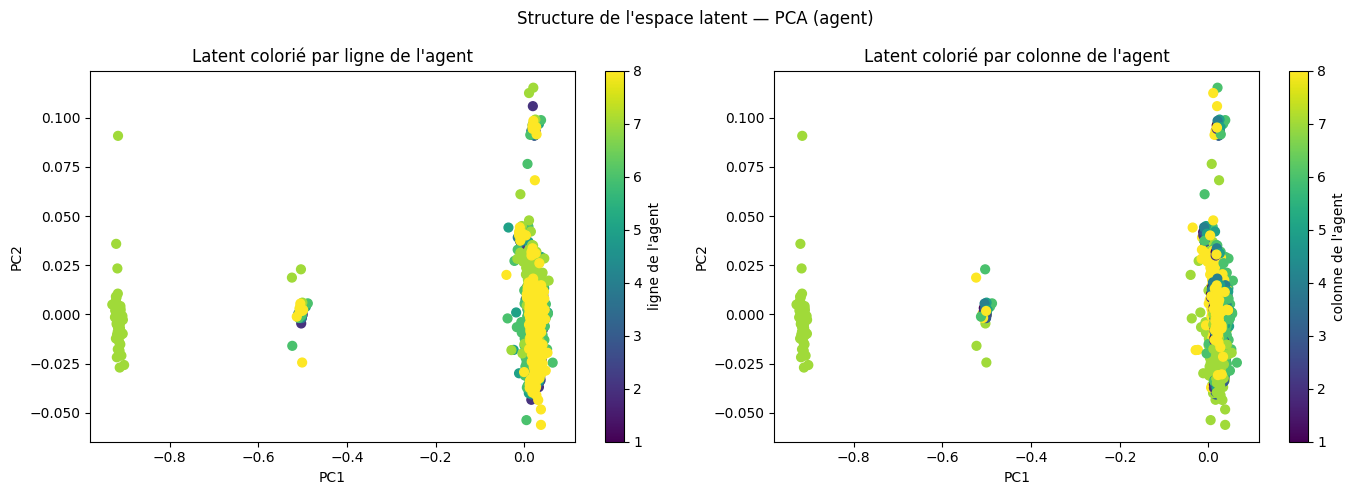

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=agent_rows, s=40)
axes[0].set_title("Latent colorié par ligne de l'agent")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="ligne de l'agent")

sc2 = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1], c=agent_cols, s=40)
axes[1].set_title("Latent colorié par colonne de l'agent")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="colonne de l'agent")

plt.suptitle("Structure de l'espace latent — PCA (agent)")
plt.tight_layout()
plt.show()

## 8. Structure du latent — position de la boîte

On regarde maintenant si la boîte est elle aussi organisée
dans l'espace latent.

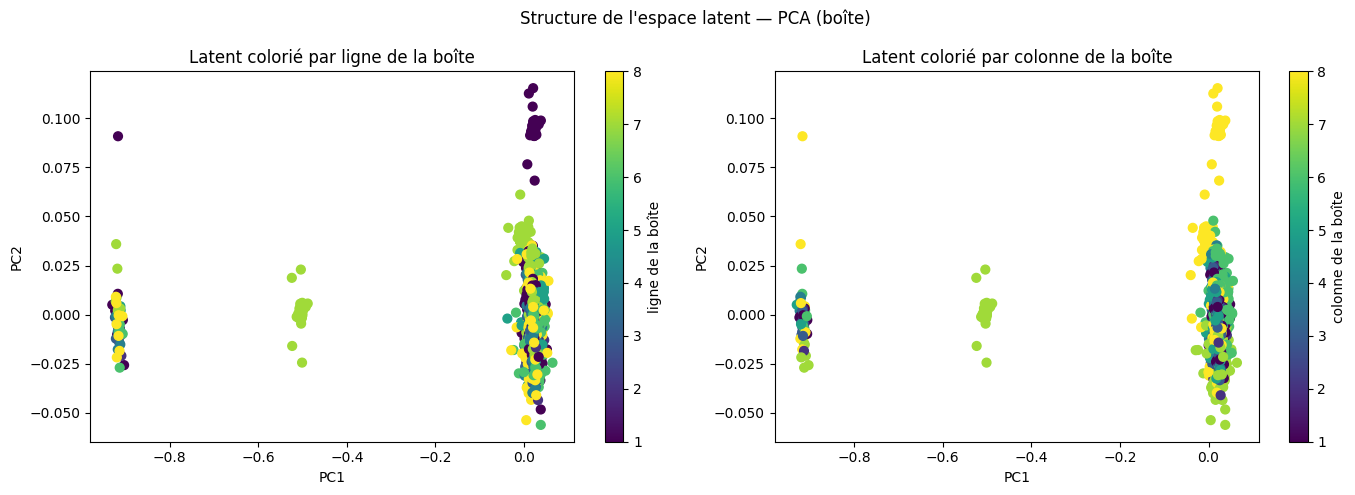

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=box_rows, s=40)
axes[0].set_title("Latent colorié par ligne de la boîte")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="ligne de la boîte")

sc2 = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1], c=box_cols, s=40)
axes[1].set_title("Latent colorié par colonne de la boîte")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="colonne de la boîte")

plt.suptitle("Structure de l'espace latent — PCA (boîte)")
plt.tight_layout()
plt.show()

## 9. Sauvegarde des visualisations PCA

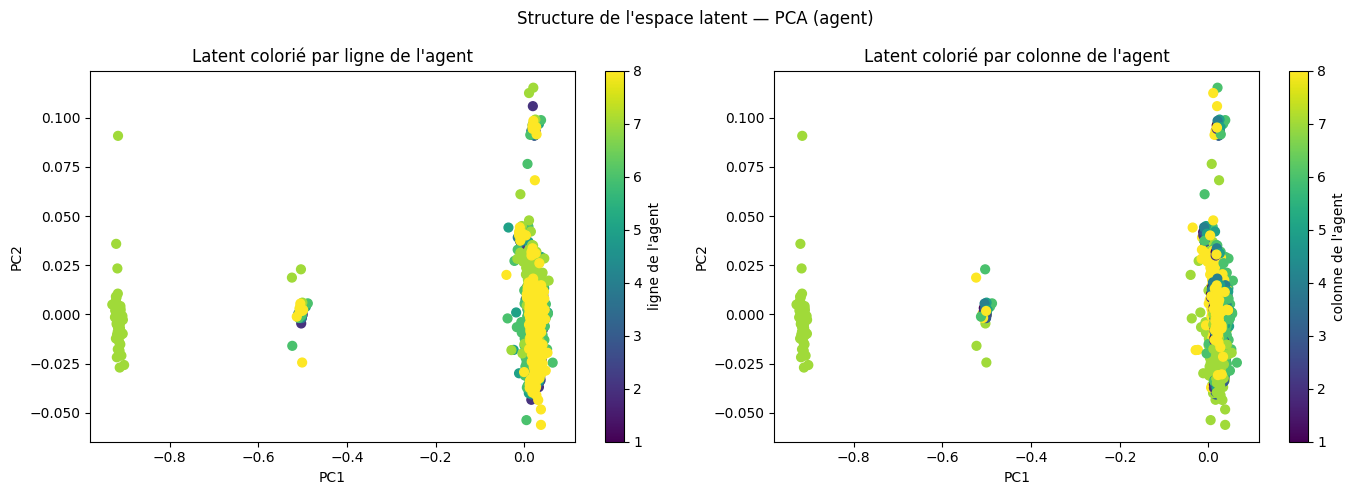

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=agent_rows, s=40)
axes[0].set_title("Latent colorié par ligne de l'agent")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="ligne de l'agent")

sc2 = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1], c=agent_cols, s=40)
axes[1].set_title("Latent colorié par colonne de l'agent")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="colonne de l'agent")

plt.suptitle("Structure de l'espace latent — PCA (agent)")
plt.tight_layout()
plt.savefig("../assets/03_latent_pca_v3.png", dpi=150, bbox_inches="tight")
plt.show()

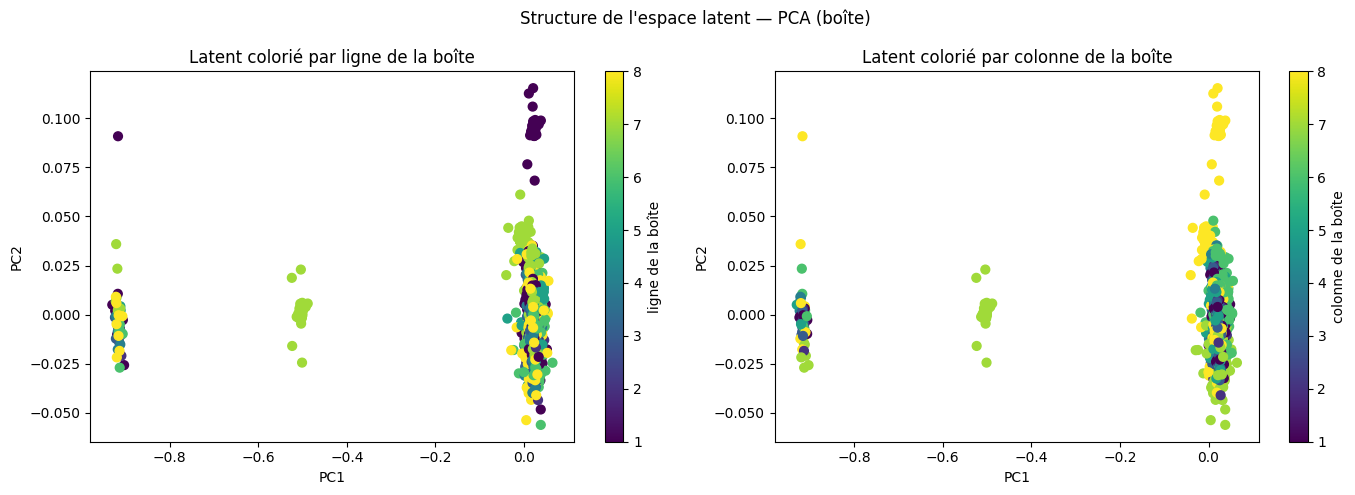

Figures PCA v3 sauvegardées ✔️


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], c=box_rows, s=40)
axes[0].set_title("Latent colorié par ligne de la boîte")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="ligne de la boîte")

sc2 = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1], c=box_cols, s=40)
axes[1].set_title("Latent colorié par colonne de la boîte")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="colonne de la boîte")

plt.suptitle("Structure de l'espace latent — PCA (boîte)")
plt.tight_layout()
plt.savefig("../assets/03_latent_pca_box_v3.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figures PCA v3 sauvegardées ✔️")

## 10. Probing classique — position de l'agent

On teste maintenant si la position de l'agent peut être récupérée
linéairement à partir du latent.

Cela ne dit pas tout, mais c'est un premier indicateur
d'interprétabilité.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(latents, agent_rows, test_size=0.2, random_state=42)

probe_agent_row = LinearRegression()
probe_agent_row.fit(X_train, y_train)
pred = probe_agent_row.predict(X_test)

r2_agent_row = r2_score(y_test, pred)
print("R² ligne agent :", r2_agent_row)


X_train, X_test, y_train, y_test = train_test_split(latents, agent_cols, test_size=0.2, random_state=42)

probe_agent_col = LinearRegression()
probe_agent_col.fit(X_train, y_train)
pred = probe_agent_col.predict(X_test)

r2_agent_col = r2_score(y_test, pred)
print("R² colonne agent :", r2_agent_col)

R² ligne agent : 0.6113492250442505
R² colonne agent : 0.3987003564834595


## 11. Probing classique — position de la boîte

Même logique pour la boîte.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(latents, box_rows, test_size=0.2, random_state=42)

probe_box_row = LinearRegression()
probe_box_row.fit(X_train, y_train)
pred = probe_box_row.predict(X_test)

r2_box_row = r2_score(y_test, pred)
print("R² ligne boîte :", r2_box_row)


X_train, X_test, y_train, y_test = train_test_split(latents, box_cols, test_size=0.2, random_state=42)

probe_box_col = LinearRegression()
probe_box_col.fit(X_train, y_train)
pred = probe_box_col.predict(X_test)

r2_box_col = r2_score(y_test, pred)
print("R² colonne boîte :", r2_box_col)

R² ligne boîte : 0.6815458536148071
R² colonne boîte : 0.6843218803405762


## 12. Probing physique — les lois du monde

Le v3 a été entraîné sur des lois physiques explicites.

Il est donc naturel de tester si le latent encode directement certaines
propriétés du monde, par exemple :

- la boîte est-elle sur la cible ?
- la boîte est-elle contre un mur ?
- l'agent est-il adjacent à la boîte ?

Ces probes sont souvent plus intéressants qu'un simple probe de coordonnées,
car ils sont alignés avec la dynamique du monde.

In [13]:
def probe_binary_property(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    print(f"Accuracy {name} : {acc:.4f}")


probe_binary_property(latents, box_on_target_flags, "box_on_target")
probe_binary_property(latents, box_against_wall_flags, "box_against_wall")
probe_binary_property(latents, agent_adjacent_to_box_flags, "agent_adjacent_to_box")

Accuracy box_on_target : 0.9839
Accuracy box_against_wall : 0.5737
Accuracy agent_adjacent_to_box : 0.9442


## 12bis. Probe relationnel — boîte sur sa cible avec cible variable

Dans les probes précédents, la cible était fixée pour simplifier l'analyse.

Cela permettait de mieux visualiser certaines structures du latent,
mais rendait le test `box_on_target` ambigu :
le probe pouvait en partie apprendre une position absolue de boîte,
plutôt qu'une relation générale entre boîte et cible.

On construit donc ici un nouveau probe plus rigoureux :

- la cible varie
- la boîte varie
- le label vaut 1 si `box == target`, 0 sinon

👉 Ce probe teste réellement la relation :
**"la boîte est-elle sur sa cible ?"**

In [14]:
def build_relation_probe_dataset_box_on_target(n_samples=4000, size=10):
    env = GridWorld(size=size)

    X = []
    y = []

    while len(X) < n_samples:
        agent = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))
        box = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))

        if agent == box:
            continue

        if np.random.rand() < 0.5:
            target = box
            label = 1
        else:
            while True:
                target = (np.random.randint(1, size - 1), np.random.randint(1, size - 1))
                if target != box and target != agent:
                    break
            label = 0

        env.set_state(agent=agent, box=box, target=target)
        grid = env.render()
        z = encode_grid(grid)

        X.append(z)
        y.append(label)

    return np.array(X), np.array(y)


X_rel, y_rel = build_relation_probe_dataset_box_on_target(n_samples=4000, size=10)

print("Shape X_rel :", X_rel.shape)
print("Proportion positive :", y_rel.mean())

Shape X_rel : (4000, 32)
Proportion positive : 0.5015


## 12ter. Évaluation du probe relationnel

On entraîne maintenant un classifieur logistique sur ce nouveau dataset
où la cible varie réellement.

Le score obtenu est beaucoup plus informatif que le probe précédent
pour juger si le latent encode la relation `box == target`.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rel, y_rel, test_size=0.2, random_state=42, stratify=y_rel
)

probe_relation_box_on_target = LogisticRegression(max_iter=2000)
probe_relation_box_on_target.fit(X_train, y_train)

pred = probe_relation_box_on_target.predict(X_test)
acc_relation_box_on_target = accuracy_score(y_test, pred)

print("Accuracy relationnelle box == target :", acc_relation_box_on_target)

Accuracy relationnelle box == target : 0.58625


## 13. Interprétation des résultats

Les résultats obtenus montrent que le latent appris par le modèle v3
est structuré, mais pas de manière parfaitement relationnelle.

---

### 1. Structure globale du latent

Les visualisations PCA montrent une organisation en amas et en structures
non triviales.

Le latent ne semble pas représenter directement une grille cartésienne,
mais plutôt organiser les états selon des configurations similaires.

---

### 2. Position de l'agent

- R² ligne agent ≈ 0.61
- R² colonne agent ≈ 0.40

La position de l'agent est partiellement encodée,
mais pas de manière parfaitement linéaire.

---

### 3. Position de la boîte

- R² ligne boîte ≈ 0.68
- R² colonne boîte ≈ 0.68

La position de la boîte est mieux encodée que celle de l'agent.

Cela est cohérent avec le rôle central de la boîte dans la dynamique :
elle détermine les interactions utiles (poussée, blocage, etc.).

---

### 4. Propriétés physiques locales

- Accuracy agent_adjacent_to_box ≈ 0.94
- Accuracy box_against_wall ≈ 0.57

Le modèle encode très bien certaines relations locales,
comme la proximité agent / boîte.

En revanche, certaines propriétés globales (comme "contre mur")
sont moins clairement représentées.

---

### 5. Relation boîte / cible (test rigoureux)

Un probe relationnel avec cible variable donne :

- Accuracy box == target ≈ 0.59

Ce résultat est fondamental :

👉 le latent n'encode pas fortement la relation générale
"la boîte est sur sa cible".

Cela signifie que :

- le modèle ne représente pas explicitement ce concept relationnel
- ou qu'il le code de manière non linéaire et difficilement décodable

---

## 💡 Lecture globale

Le latent encode principalement :

- la position des objets (surtout la boîte)
- des relations locales importantes (adjacence)
- certaines configurations physiques utiles à la dynamique

Mais il n'encode pas clairement :

- des relations globales abstraites comme `box == target`

👉 Le modèle semble donc organiser sa représentation autour de
ce qui est utile pour prédire la dynamique locale,
plutôt que pour représenter explicitement des objectifs.

## ✅ Conclusion de l'acte 3

L'analyse du latent du modèle v3 montre une représentation structurée,
mais orientée vers la dynamique locale plutôt que vers des concepts globaux.

---

### Ce que le modèle encode bien

- la position de la boîte (meilleur signal que l'agent)
- certaines relations locales (agent proche de la boîte)
- des configurations utiles pour prédire les transitions

---

### Ce que le modèle encode moins bien

- des relations abstraites globales comme :
  `la boîte est sur la cible`

Le test relationnel avec cible variable (accuracy ≈ 0.59)
montre que ce concept n'est pas explicitement représenté
dans l'espace latent.

---

## 🎯 Interprétation

Le modèle a appris un **modèle du monde local** :

- comment les objets interagissent
- comment les mouvements affectent l'environnement
- quelles configurations permettent une poussée

Mais il n'a pas appris un modèle orienté objectif.

👉 La cible influence la dynamique (blocage),
mais n'est pas représentée comme un concept central du latent.

---

## 💡 Implication pour le planning

Cela explique directement les difficultés rencontrées dans l'acte 4 :

- un coût basé sur `box == target` est difficile à apprendre
- le modèle ne fournit pas un signal clair pour ce type d'objectif

👉 Il faudra donc utiliser une autre stratégie de coût
pour exploiter le world model.

---

## Conclusion générale

Le passage à un dataset dirigé par lois physiques a permis :

- un apprentissage stable
- une dynamique cohérente en rollout
- une représentation latente structurée

Mais cette représentation reste centrée sur la physique locale,
et non sur des objectifs globaux.

👉 Le modèle comprend le monde, mais pas encore le but.